# Diagnosing the adaptive persistence-image sigma

Section 3.6 of `pi_multik_report.tex` found that the per-diagram adaptive $\sigma$
(`sigma_frac * median(persistence)`, floored at `min_sigma_pixels`) sits at its floor
for essentially every $H_0$ diagram and ~99.7% of $H_1$ diagrams at the current
resolution (64) and `sigma_frac` (0.1) -- i.e. it isn't meaningfully "adaptive" on
this data. Before proposing a fix, this notebook builds three diagnostics that
characterize *what kind of problem* that actually is, run across the full
distribution of diagrams (not just a mean/summary number per config):

1. **Speckle measure** -- fraction of total image energy sitting in the top-$m$
   pixels. High → the image is a scatter of near-delta spikes → **under-smoothed**.
2. **Effective resolvable structure** -- number of connected components above a
   relative-intensity threshold, and the participation ratio of their masses
   ($\mathrm{PR}=(\sum_c M_c)^2/\sum_c M_c^2$, which equals the component count when
   masses are equal and drops below it as one component dominates). Collapsing
   toward 1 → nearby features have been smeared into one blob → **over-smoothed**.
3. **Empirical stability** -- perturb the input point cloud, recompute its diagram,
   and measure $\lVert\Delta\text{PI}\rVert_2$ against the bottleneck/Wasserstein
   distance between the original and perturbed diagrams. The classical
   fixed-$\sigma$ persistence-image construction is provably Lipschitz in this
   sense (Adams et al. 2017); making $\sigma$ a function of the diagram itself
   (as the adaptive mechanism does) is *not* automatically covered by that
   guarantee, since the map diagram → image is no longer $\sigma$-independent of
   its own input. A design with a tight, roughly-linear $\Delta\text{PI}$-vs-diagram-distance
   relationship is preserving what persistence images are theoretically for; a
   design with a loose, high-variance, or discontinuous-looking relationship is not
   -- this is the diagnostic that would catch a proposed sigma design breaking that
   property, whatever the specific design.

**Scope.** Two designs are compared, isolating just the sigma mechanism (same
resolution, same bounds, same point-weighting -- following the sigma-only ablation
already established in `compare_pi_adaptive_sigma.ipynb`):

- **`adaptive`** -- today's shipped mechanism (`sigma_frac=0.1`, `sigma_stat="median"`,
  `min_sigma_pixels=1.0`).
- **`fixed`** -- the legacy constant $\sigma=0.05$, reconstructed through the *same*
  `PersistenceImager` class (not a reimplementation): setting `sigma_frac=0` makes
  `max(sigma_frac*spread, min_sigma_pixels*pixel)` always take the floor, and solving
  `min_sigma_pixels = fixed_sigma / pixel` makes that floor land exactly on 0.05.

Data: **nested Thomas**, all three swept DTM scales ($k\in\{5,10,15\}$), via
`data/legacy/nested_thomas/` -- chosen (as in the existing notebook) because its
`clouds.pkl`/`diagrams.pkl`/legacy `persistence_image.pkl` are a matched triple for
every $k$, which is required for diagnostic 3 (it needs the raw point clouds, not
just diagrams, to perturb and re-filter).

In [ ]:
import pickle
import sys
import time
from pathlib import Path

import gudhi
import matplotlib.pyplot as plt
import numpy as np
import persim
from scipy import ndimage

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "_attic" / "vectorizers_retired"))

from cloudforger.core.calibration import axis_bounds, calibrate
from cloudforger.core.cloud import PointCloud
from cloudforger.core.records import load_diagrams, to_pointcloud
from cloudforger.filtration import REGISTRY as FILTRATION_REGISTRY
from cloudforger.vectorizers.multi_channel import MultiChannelImager
from adaptive_persistence_image import PersistenceImager  # retired design, archived to _attic/vectorizers_retired/; see persistence_image.py for its paper-faithful replacement

OUT = ROOT / "notebooks" / "out"
OUT.mkdir(parents=True, exist_ok=True)

K_VALUES = [5, 10, 15]
HOMOLOGY_DIMS = (0, 1)
LEGACY_ROOT = ROOT / "data" / "legacy" / "nested_thomas"
RESOLUTION = 128
FIXED_SIGMA = 0.05  # legacy's own fixed sigma (see notebooks/compare_pi_adaptive_sigma.ipynb)

FIXED_COLOR = "#2a78d6"     # legacy-fixed-sigma design -- always this color
ADAPTIVE_COLOR = "#eb6834"  # current adaptive-sigma design -- always this color
DESIGN_COLORS = {"fixed": FIXED_COLOR, "adaptive": ADAPTIVE_COLOR}

In [2]:
diagrams_by_k = {}
clouds_by_seed_by_k = {}
for k in K_VALUES:
    diagrams, _bundle = load_diagrams(LEGACY_ROOT / f"dtm_k{k}" / "diagrams.pkl")
    diagrams_by_k[k] = diagrams
    print(f"k={k}: {len(diagrams)} diagrams")

with open(LEGACY_ROOT / "clouds.pkl", "rb") as f:
    cloud_records = pickle.load(f)
clouds_by_seed = {r["seed"]: to_pointcloud(r) for r in cloud_records}
print(f"{len(clouds_by_seed)} point clouds loaded (shared across k)")

k=5: 846 diagrams
k=10: 846 diagrams
k=15: 841 diagrams
848 point clouds loaded (shared across k)


## Building the two comparable designs

Both share bounds/resolution/weighting (calibrated once per $k$ from that $k$'s own
diagrams, same convention as `build_calibrated_imager`); only the sigma mechanism
differs.

In [3]:
def build_two_designs(diagrams, resolution=RESOLUTION, fixed_sigma=FIXED_SIGMA):
    stats = calibrate(diagrams)
    adaptive_imagers, fixed_imagers = {}, {}
    for dim in HOMOLOGY_DIMS:
        birth_hi, pers_hi = axis_bounds(stats, dim)
        pixel = pers_hi / resolution
        adaptive_imagers[dim] = PersistenceImager(
            birth_range=(0.0, birth_hi), pers_range=(0.0, pers_hi),
            resolution=resolution, sigma_frac=0.1, sigma_stat="median",
            min_sigma_pixels=1.0, weight=True,
        )
        fixed_imagers[dim] = PersistenceImager(
            birth_range=(0.0, birth_hi), pers_range=(0.0, pers_hi),
            resolution=resolution, sigma_frac=0.0, sigma_stat="median",
            min_sigma_pixels=fixed_sigma / pixel, weight=True,
        )
    return {"adaptive": MultiChannelImager(adaptive_imagers), "fixed": MultiChannelImager(fixed_imagers)}


designs_by_k = {k: build_two_designs(diagrams_by_k[k]) for k in K_VALUES}
for k in K_VALUES:
    for dim in HOMOLOGY_DIMS:
        fp = designs_by_k[k]["fixed"].params[dim]
        print(f"k={k} dim={dim}: fixed sigma reconstructed = "
              f"{fp['min_sigma_pixels'] * (fp['pers_range'][1] / fp['resolution']):.4f} (target {FIXED_SIGMA})")

k=5 dim=0: fixed sigma reconstructed = 0.0500 (target 0.05)
k=5 dim=1: fixed sigma reconstructed = 0.0500 (target 0.05)
k=10 dim=0: fixed sigma reconstructed = 0.0500 (target 0.05)
k=10 dim=1: fixed sigma reconstructed = 0.0500 (target 0.05)
k=15 dim=0: fixed sigma reconstructed = 0.0500 (target 0.05)
k=15 dim=1: fixed sigma reconstructed = 0.0500 (target 0.05)


## Diagnostic 1 -- speckle measure

Fraction of total image energy in the top-$m$ pixels, $m$ a small percentage of the
$128\times128=16384$-pixel grid. Computed at three $m$ thresholds for robustness;
plots use 1%.

In [4]:
def speckle_measure(image: np.ndarray, top_frac: float) -> float:
    total = image.sum()
    if total <= 0:
        return np.nan
    m = max(1, round(top_frac * image.size))
    top_sum = np.partition(image.ravel(), -m)[-m:].sum()
    return float(top_sum / total)


TOP_FRACS = [0.001, 0.01, 0.05]

speckle_results = {}  # (k, dim, design, top_frac) -> np.ndarray over diagrams
for k in K_VALUES:
    for dim in HOMOLOGY_DIMS:
        for name, imager in designs_by_k[k].items():
            images = [imager.transform(d)[dim] for d in diagrams_by_k[k]]
            for tf in TOP_FRACS:
                vals = np.array([speckle_measure(im, tf) for im in images])
                speckle_results[(k, dim, name, tf)] = vals

print(f"{'k':>3} {'dim':>4} {'design':>9} {'top%':>6} {'median':>8} {'p90':>8} {'n_nonempty':>11}")
for k in K_VALUES:
    for dim in HOMOLOGY_DIMS:
        for name in ("fixed", "adaptive"):
            for tf in TOP_FRACS:
                v = speckle_results[(k, dim, name, tf)]
                v = v[~np.isnan(v)]
                print(f"{k:>3} {dim:>4} {name:>9} {tf*100:>5.1f}% {np.median(v):>8.3f} "
                      f"{np.percentile(v, 90):>8.3f} {len(v):>11}")

  k  dim    design   top%   median      p90  n_nonempty
  5    0     fixed   0.1%    0.006    0.009         846
  5    0     fixed   1.0%    0.056    0.092         846
  5    0     fixed   5.0%    0.255    0.393         846
  5    0  adaptive   0.1%    0.130    0.265         846
  5    0  adaptive   1.0%    0.597    0.847         846
  5    0  adaptive   5.0%    0.986    1.000         846
  5    1     fixed   0.1%    0.004    0.006         759
  5    1     fixed   1.0%    0.036    0.056         759
  5    1     fixed   5.0%    0.170    0.254         759
  5    1  adaptive   0.1%    0.743    0.996         759
  5    1  adaptive   1.0%    1.000    1.000         759
  5    1  adaptive   5.0%    1.000    1.000         759
 10    0     fixed   0.1%    0.005    0.008         841
 10    0     fixed   1.0%    0.054    0.084         841
 10    0     fixed   5.0%    0.246    0.366         841
 10    0  adaptive   0.1%    0.132    0.268         841
 10    0  adaptive   1.0%    0.590    0.853     

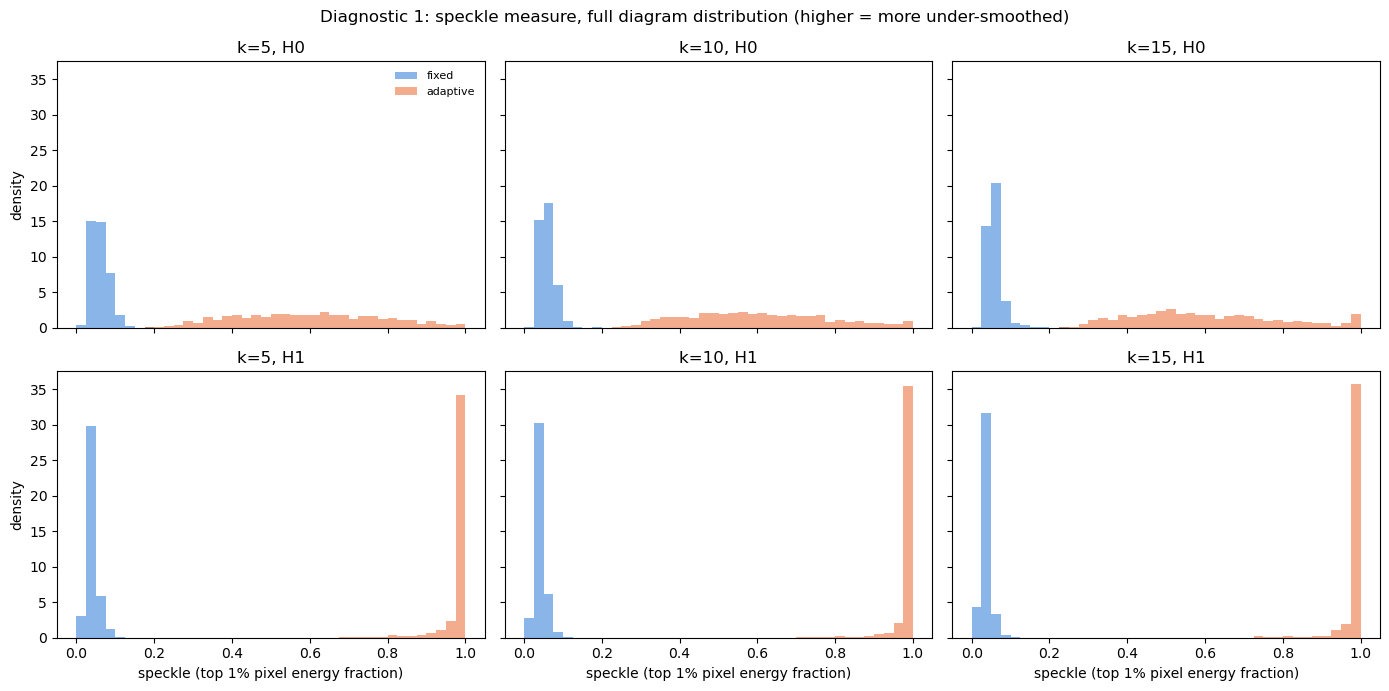

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
bins = np.linspace(0, 1, 41)
for col, k in enumerate(K_VALUES):
    for row, dim in enumerate(HOMOLOGY_DIMS):
        ax = axes[row, col]
        for name in ("fixed", "adaptive"):
            v = speckle_results[(k, dim, name, 0.01)]
            v = v[~np.isnan(v)]
            ax.hist(v, bins=bins, color=DESIGN_COLORS[name], alpha=0.55, label=name, density=True)
        ax.set_title(f"k={k}, H{dim}")
        if row == 1:
            ax.set_xlabel("speckle (top 1% pixel energy fraction)")
        if col == 0:
            ax.set_ylabel("density")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Diagnostic 1: speckle measure, full diagram distribution (higher = more under-smoothed)")
fig.tight_layout()
fig.savefig(OUT / "05_speckle_distributions.png", dpi=150)
plt.show()

## Diagnostic 2 -- effective resolvable structure

Binarize each image at `rel_threshold * image.max()`, label connected components
with `scipy.ndimage.label`, and report both the raw component count and the
participation ratio of component masses $\mathrm{PR}=(\sum_c M_c)^2/\sum_c M_c^2$
(equals the count when masses are balanced, drops toward 1 as one component
dominates the rest). Computed at three thresholds for robustness; plots use 0.1.

In [6]:
def effective_resolvable_structure(image: np.ndarray, rel_threshold: float) -> tuple[int, float]:
    if image.sum() <= 0 or image.max() <= 0:
        return 0, np.nan
    mask = image >= (rel_threshold * image.max())
    labeled, n = ndimage.label(mask)
    if n == 0:
        return 0, np.nan
    masses = ndimage.sum(image, labeled, index=np.arange(1, n + 1))
    pr = float((masses.sum() ** 2) / (masses ** 2).sum())
    return int(n), pr


REL_THRESHOLDS = [0.05, 0.1, 0.2]

structure_results = {}  # (k, dim, design, thresh) -> (ncomp array, pr array)
for k in K_VALUES:
    for dim in HOMOLOGY_DIMS:
        for name, imager in designs_by_k[k].items():
            images = [imager.transform(d)[dim] for d in diagrams_by_k[k]]
            for th in REL_THRESHOLDS:
                pairs = [effective_resolvable_structure(im, th) for im in images]
                ncomp = np.array([p[0] for p in pairs])
                pr = np.array([p[1] for p in pairs])
                structure_results[(k, dim, name, th)] = (ncomp, pr)

print(f"{'k':>3} {'dim':>4} {'design':>9} {'thresh':>7} {'median n_comp':>14} {'frac<=1':>8} {'median PR':>10}")
for k in K_VALUES:
    for dim in HOMOLOGY_DIMS:
        for name in ("fixed", "adaptive"):
            for th in REL_THRESHOLDS:
                ncomp, pr = structure_results[(k, dim, name, th)]
                nz = ncomp[ncomp > 0]
                print(f"{k:>3} {dim:>4} {name:>9} {th:>7.2f} {np.median(nz):>14.1f} "
                      f"{np.mean(ncomp <= 1):>8.2f} {np.nanmedian(pr):>10.2f}")

  k  dim    design  thresh  median n_comp  frac<=1  median PR
  5    0     fixed    0.05            1.0     0.97       1.00
  5    0     fixed    0.10            1.0     0.94       1.00
  5    0     fixed    0.20            1.0     0.91       1.00
  5    0  adaptive    0.05           16.0     0.00       3.93
  5    0  adaptive    0.10           17.0     0.00       4.45
  5    0  adaptive    0.20           13.0     0.00       4.45
  5    1     fixed    0.05            1.0     0.98       1.00
  5    1     fixed    0.10            1.0     0.96       1.00
  5    1     fixed    0.20            1.0     0.94       1.00
  5    1  adaptive    0.05            6.0     0.22       3.03
  5    1  adaptive    0.10            4.0     0.24       2.84
  5    1  adaptive    0.20            3.0     0.30       2.34
 10    0     fixed    0.05            1.0     0.97       1.00
 10    0     fixed    0.10            1.0     0.94       1.00
 10    0     fixed    0.20            1.0     0.94       1.00
 10    0

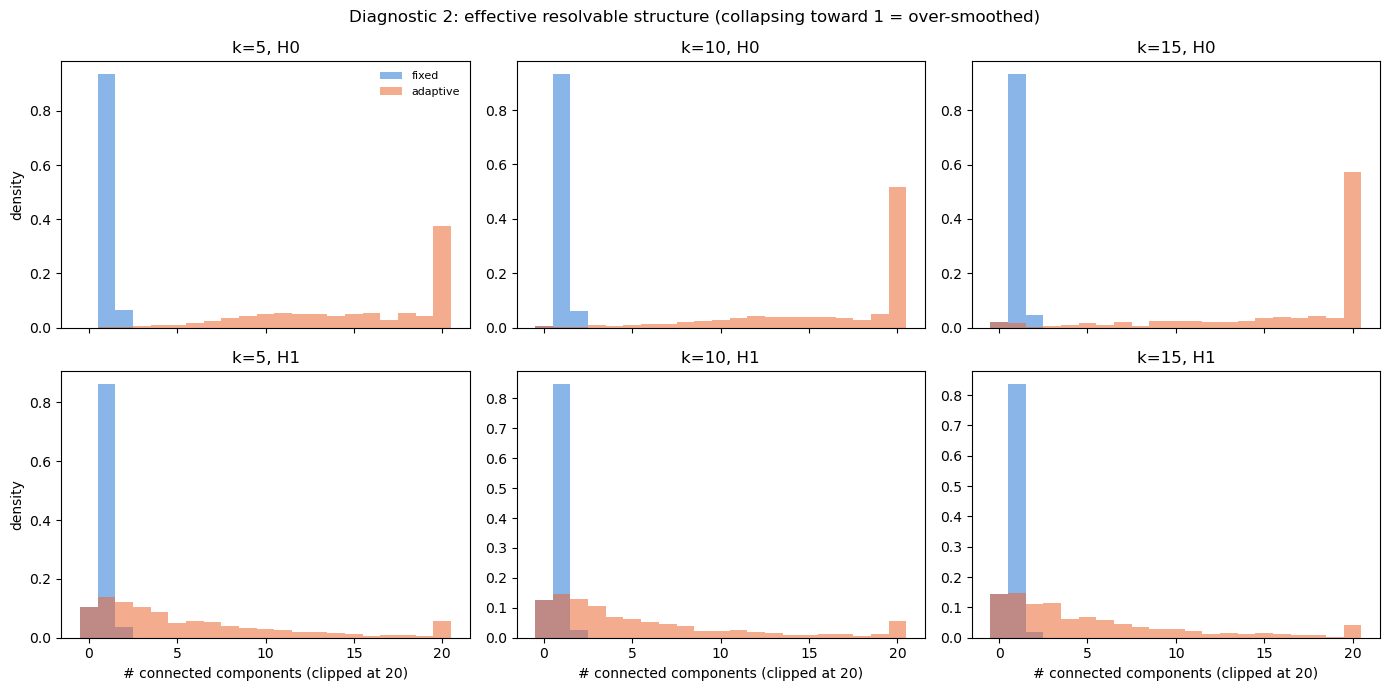

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
max_ncomp = 20
bins = np.arange(0, max_ncomp + 2) - 0.5
for col, k in enumerate(K_VALUES):
    for row, dim in enumerate(HOMOLOGY_DIMS):
        ax = axes[row, col]
        for name in ("fixed", "adaptive"):
            ncomp, _pr = structure_results[(k, dim, name, 0.1)]
            ncomp = np.clip(ncomp, 0, max_ncomp)
            ax.hist(ncomp, bins=bins, color=DESIGN_COLORS[name], alpha=0.55, label=name, density=True)
        ax.set_title(f"k={k}, H{dim}")
        if row == 1:
            ax.set_xlabel(f"# connected components (clipped at {max_ncomp})")
        if col == 0:
            ax.set_ylabel("density")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Diagnostic 2: effective resolvable structure (collapsing toward 1 = over-smoothed)")
fig.tight_layout()
fig.savefig(OUT / "06_component_count_distributions.png", dpi=150)
plt.show()

## Diagnostic 3 -- empirical stability

For a sample of clouds per $k$, jitter every point with i.i.d. Gaussian noise at a
few noise scales, recompute the DTM diagram with the *same* filtration (`k`
unchanged), and compare against the original diagram both as raw diagrams
(bottleneck and 1-Wasserstein distance, via `gudhi`/`persim`) and as persistence
images ($\lVert\Delta\text{PI}\rVert_2$, per design).

**Compute note.** `DTMRipsComplex` scales worse than quadratically in point count
(≈0.5s at $n{=}300$, ≈6s at $n{=}600$ on this machine) -- candidates are restricted
to clouds with $30 \le n \le 350$ points (covers the bulk of the distribution, up
through roughly its 90th percentile) so the full sweep finishes in a few minutes;
`N_SAMPLE`/`NOISE_LEVELS`/`N_REPEATS` below are deliberately modest defaults for a
first pass and can be raised for a more exhaustive run.

In [8]:
N_SAMPLE = 60
NOISE_LEVELS = [0.005, 0.015, 0.04]
N_REPEATS = 2
N_POINTS_RANGE = (30, 350)
RNG = np.random.default_rng(0)


def jitter_cloud(cloud: PointCloud, sigma: float, rng: np.random.Generator) -> PointCloud:
    noise = rng.normal(scale=sigma, size=cloud.points.shape)
    return PointCloud(
        points=cloud.points + noise, generator_name=cloud.generator_name,
        generator_params=cloud.generator_params, seed=cloud.seed,
        region=cloud.region, covariates=cloud.covariates,
    )


def diagram_distance(pairs_a, pairs_b, kind):
    if len(pairs_a) == 0 and len(pairs_b) == 0:
        return 0.0
    if kind == "bottleneck":
        return float(gudhi.bottleneck_distance(pairs_a, pairs_b))
    return float(persim.wasserstein(pairs_a, pairs_b))


stability_rows = []  # dicts: k, seed, eps, repeat, dim, design, bottleneck, wasserstein, delta_pi
t_start = time.time()
for k in K_VALUES:
    filt = FILTRATION_REGISTRY.build("dtm", k=k)
    designs = designs_by_k[k]
    candidates = [
        d for d in diagrams_by_k[k]
        if d.seed in clouds_by_seed and N_POINTS_RANGE[0] <= clouds_by_seed[d.seed].n_points <= N_POINTS_RANGE[1]
    ]
    sample_idx = RNG.choice(len(candidates), size=min(N_SAMPLE, len(candidates)), replace=False)
    print(f"k={k}: {len(candidates)} eligible diagrams (n_points in {N_POINTS_RANGE}), sampling {len(sample_idx)}")

    for i in sample_idx:
        d = candidates[i]
        cloud = clouds_by_seed[d.seed]
        for eps in NOISE_LEVELS:
            for rep in range(N_REPEATS):
                d_pert = filt.compute(jitter_cloud(cloud, eps, RNG))
                for dim in HOMOLOGY_DIMS:
                    pa, pb = d.finite_pairs(dim), d_pert.finite_pairs(dim)
                    bd = diagram_distance(pa, pb, "bottleneck")
                    wd = diagram_distance(pa, pb, "wasserstein")
                    for name, imager in designs.items():
                        delta = float(np.linalg.norm(imager.transform(d)[dim] - imager.transform(d_pert)[dim]))
                        stability_rows.append(dict(
                            k=k, seed=d.seed, eps=eps, repeat=rep, dim=dim, design=name,
                            bottleneck=bd, wasserstein=wd, delta_pi=delta,
                        ))
    print(f"  ... {time.time() - t_start:.0f}s elapsed")

print(f"\n{len(stability_rows)} (cloud, eps, repeat, dim, design) rows collected in {time.time() - t_start:.0f}s")

k=5: 692 eligible diagrams (n_points in (30, 350)), sampling 60


  ... 62s elapsed
k=10: 692 eligible diagrams (n_points in (30, 350)), sampling 60


  ... 127s elapsed
k=15: 692 eligible diagrams (n_points in (30, 350)), sampling 60


  ... 200s elapsed

4320 (cloud, eps, repeat, dim, design) rows collected in 200s


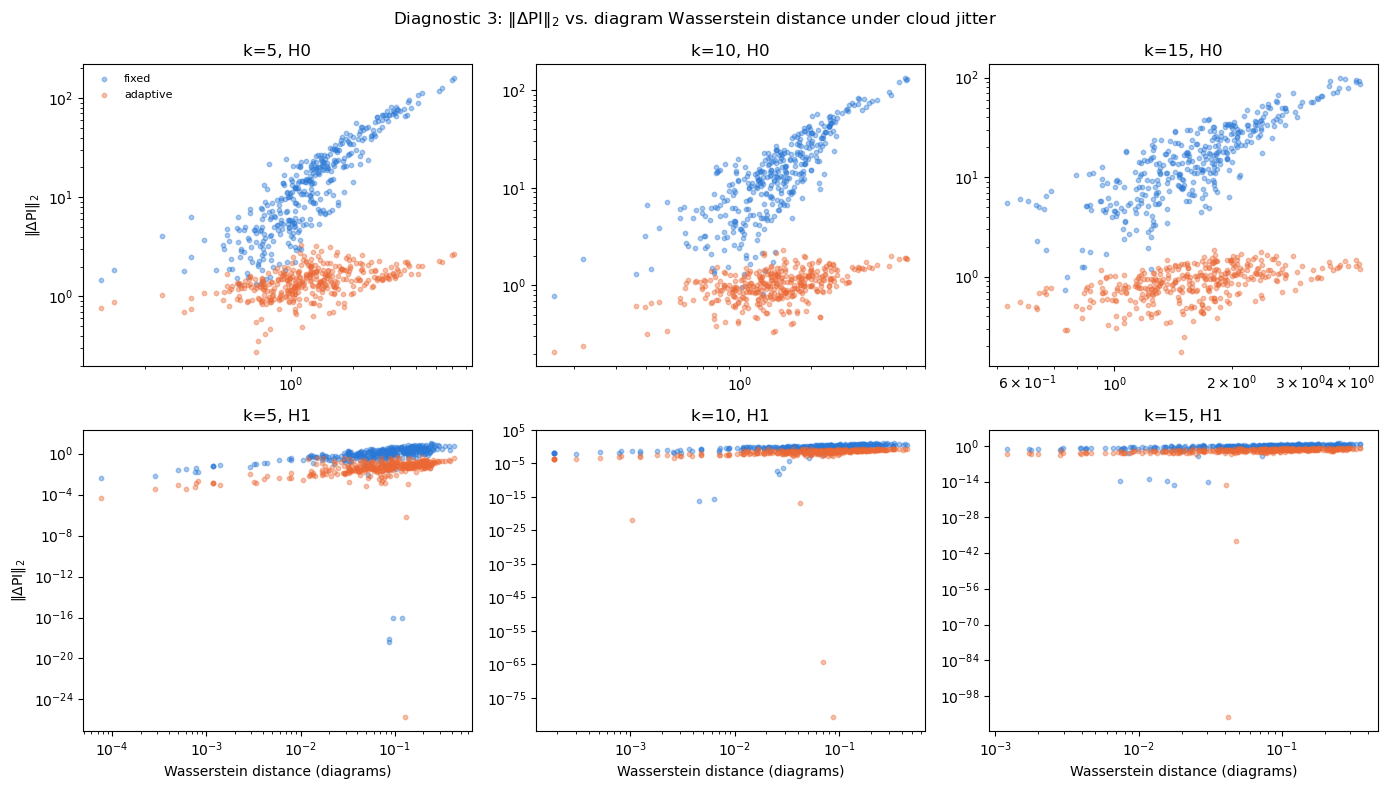

In [9]:
def field(rows, name):
    return np.array([r[name] for r in rows])


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, k in enumerate(K_VALUES):
    for row, dim in enumerate(HOMOLOGY_DIMS):
        ax = axes[row, col]
        for name in ("fixed", "adaptive"):
            rows = [r for r in stability_rows if r["k"] == k and r["dim"] == dim and r["design"] == name]
            w = field(rows, "wasserstein")
            dpi = field(rows, "delta_pi")
            ax.scatter(w, dpi, s=10, alpha=0.4, color=DESIGN_COLORS[name], label=name)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(f"k={k}, H{dim}")
        if row == 1:
            ax.set_xlabel("Wasserstein distance (diagrams)")
        if col == 0:
            ax.set_ylabel(r"$\|\Delta\mathrm{PI}\|_2$")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle(r"Diagnostic 3: $\|\Delta\mathrm{PI}\|_2$ vs. diagram Wasserstein distance under cloud jitter")
fig.tight_layout()
fig.savefig(OUT / "07_stability_scatter.png", dpi=150)
plt.show()

In [10]:
print(f"{'k':>3} {'dim':>4} {'design':>9} {'n':>5} {'pearson r':>10} {'loglog slope':>13} "
      f"{'ratio p50':>10} {'ratio p90':>10} {'ratio p99':>10}")
stability_summary = {}
for k in K_VALUES:
    for dim in HOMOLOGY_DIMS:
        for name in ("fixed", "adaptive"):
            rows = [r for r in stability_rows if r["k"] == k and r["dim"] == dim and r["design"] == name]
            w = field(rows, "wasserstein")
            dpi = field(rows, "delta_pi")
            mask = w > 0
            w, dpi = w[mask], dpi[mask]
            r_pearson = np.corrcoef(w, dpi)[0, 1] if len(w) > 1 else np.nan
            slope = np.polyfit(np.log(w), np.log(dpi + 1e-12), 1)[0] if len(w) > 1 else np.nan
            ratio = dpi / w
            stability_summary[(k, dim, name)] = dict(r=r_pearson, slope=slope, ratio=ratio)
            print(f"{k:>3} {dim:>4} {name:>9} {len(w):>5} {r_pearson:>10.3f} {slope:>13.3f} "
                  f"{np.percentile(ratio, 50):>10.3g} {np.percentile(ratio, 90):>10.3g} "
                  f"{np.percentile(ratio, 99):>10.3g}")

  k  dim    design     n  pearson r  loglog slope  ratio p50  ratio p90  ratio p99
  5    0     fixed   360      0.956         1.709         11       21.9       26.3
  5    0  adaptive   360      0.449         0.311       1.17       2.13       3.12
  5    1     fixed   354      0.657         0.717       17.1       38.9       55.1
  5    1  adaptive   354      0.387         0.658      0.605        2.2       11.2
 10    0     fixed   360      0.911         1.743       9.93       20.4       26.2
 10    0  adaptive   360      0.510         0.409      0.694       1.21       1.75
 10    1     fixed   358      0.689         1.072       15.7       40.7       55.5
 10    1  adaptive   358      0.697         1.317      0.482        1.3       4.47
 15    0     fixed   360      0.900         1.951       9.56       18.6       24.6
 15    0  adaptive   360      0.500         0.519      0.567      0.867       1.07
 15    1     fixed   360      0.692         1.369       13.5       30.5       51.4
 15 

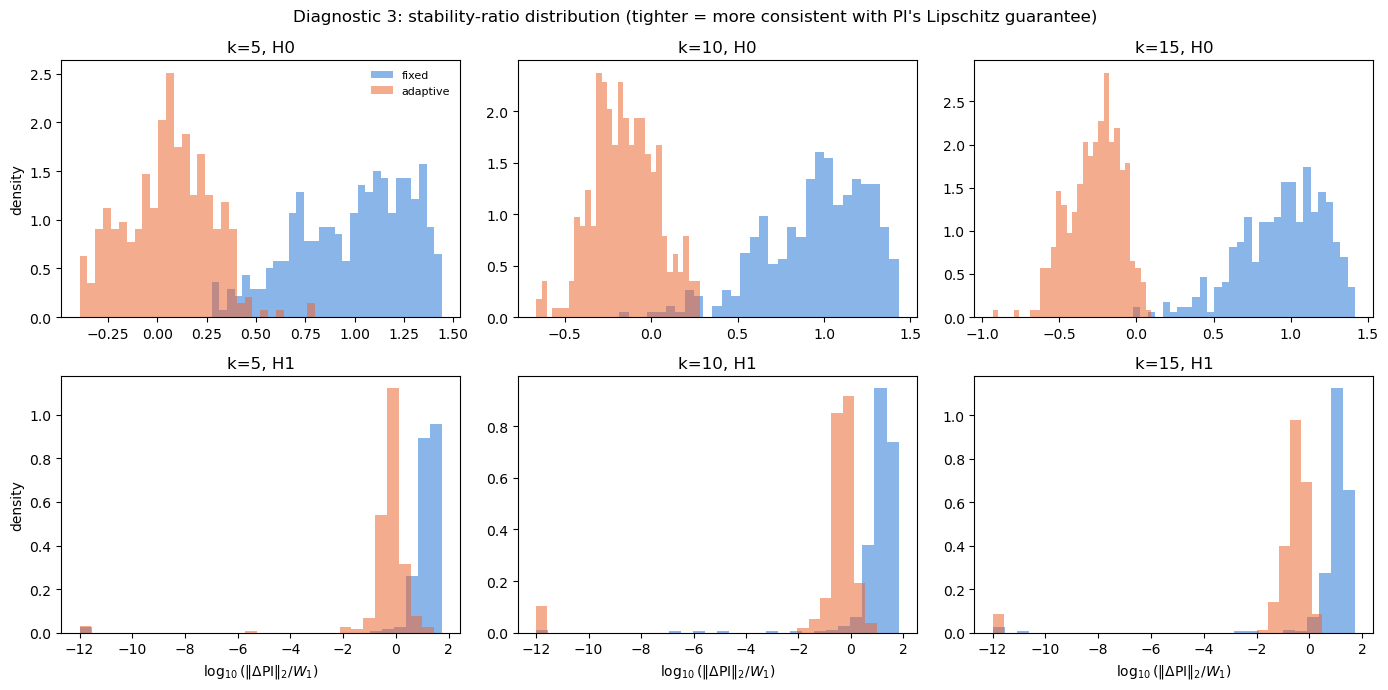

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=False)
for col, k in enumerate(K_VALUES):
    for row, dim in enumerate(HOMOLOGY_DIMS):
        ax = axes[row, col]
        for name in ("fixed", "adaptive"):
            ratio = stability_summary[(k, dim, name)]["ratio"]
            ax.hist(np.log10(ratio + 1e-12), bins=30, color=DESIGN_COLORS[name], alpha=0.55,
                    label=name, density=True)
        ax.set_title(f"k={k}, H{dim}")
        if row == 1:
            ax.set_xlabel(r"$\log_{10}(\|\Delta\mathrm{PI}\|_2 / W_1)$")
        if col == 0:
            ax.set_ylabel("density")
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Diagnostic 3: stability-ratio distribution (tighter = more consistent with PI's Lipschitz guarantee)")
fig.tight_layout()
fig.savefig(OUT / "08_stability_ratio_distributions.png", dpi=150)
plt.show()

## Reading these three diagnostics together

- **Diagnostic 1 (speckle):** a high top-1% energy fraction across most of the
  distribution (not just the mean) confirms Section 3.6's floor-binding finding is
  a genuine under-smoothing problem, not an artifact of averaging over a few
  outlier diagrams -- and shows exactly how severe it is compared to the
  legacy-fixed alternative on the very same diagrams.
- **Diagnostic 2 (effective resolvable structure):** if `fixed` collapses to a
  single component for most diagrams while `adaptive` does not, that is direct
  evidence that going back to a single hand-picked $\sigma$ is not a fix either --
  it trades under-smoothing for over-smoothing rather than solving the underlying
  problem. The honest target is a design that keeps both diagnostics away from
  their respective failure modes at once, which is the standard against which any
  future candidate sigma design should be measured.
- **Diagnostic 3 (stability):** a tight, high-correlation, roughly-linear
  (log-log slope ≈ 1) relationship between $\lVert\Delta\text{PI}\rVert_2$ and
  diagram distance -- with a narrow ratio distribution -- means the design is
  preserving the property that makes persistence images theoretically meaningful
  vectorizations of diagrams in the first place. A wide or heavy-tailed ratio
  distribution, or a slope that drifts from 1, is the signature of a design (this
  one or a future candidate) whose diagram-dependent $\sigma$ has broken that
  guarantee -- exactly the check this diagnostic exists to run before any new
  sigma design is adopted.